<a href="https://colab.research.google.com/github/Katab-sawan/Dissertation/blob/Random-Forest-Models/RandomForestNvda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import yfinance as yf
import datetime

In [ ]:
df = yf.download('NVDA', start='2012-01-01', end=datetime.datetime.now())
df = df.dropna()
df.columns = df.columns.droplevel(1)
df

/tmp/ipykernel_6817/2822422867.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('NVDA', start='2012-01-01', end=datetime.datetime.now())
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2012-01-03,0.321791,0.330043,0.321104,0.327751,468044000
2012-01-04,0.325458,0.326834,0.319041,0.322021,347372000
2012-01-05,0.337148,0.338752,0.322479,0.323854,563548000
2012-01-06,0.333251,0.337148,0.329355,0.336918,533252000
2012-01-09,0.333251,0.339669,0.330959,0.333480,508244000
...,...,...,...,...,...
2026-04-08,182.080002,185.259995,180.300003,184.500000,147732700
2026-04-09,183.910004,184.080002,180.619995,181.839996,116428500
2026-04-10,188.630005,190.000000,184.300003,184.309998,160459500


In [ ]:
df.index

DatetimeIndex(['2012-01-03', '2012-01-04', '2012-01-05', '2012-01-06',
               '2012-01-09', '2012-01-10', '2012-01-11', '2012-01-12',
               '2012-01-13', '2012-01-17',
               ...
               '2026-03-31', '2026-04-01', '2026-04-02', '2026-04-06',
               '2026-04-07', '2026-04-08', '2026-04-09', '2026-04-10',
               '2026-04-13', '2026-04-14'],
              dtype='datetime64[ns]', name='Date', length=3590, freq=None)

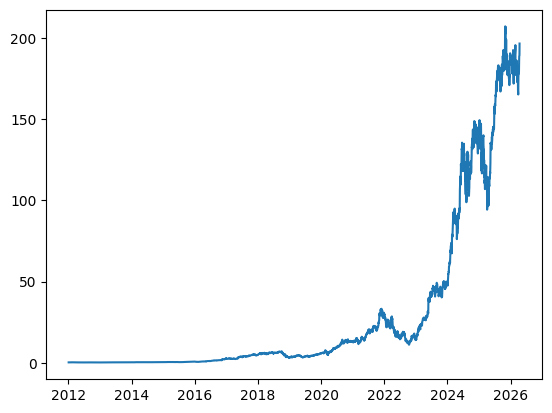

In [ ]:
plt.plot(df.index, df['Close'])

In [ ]:
df = df.reset_index()

In [ ]:
df['Date']

,Date
0,2012-01-03
1,2012-01-04
2,2012-01-05
3,2012-01-06
4,2012-01-09
...,...
3585,2026-04-08
3586,2026-04-09
3587,2026-04-10
3588,2026-04-13


(array([14610., 15340., 16071., 16801., 17532., 18262., 18993., 19723.,
        20454.]),
 [Text(14610.0, 0, '2010'),
  Text(15340.0, 0, '2012'),
  Text(16071.0, 0, '2014'),
  Text(16801.0, 0, '2016'),
  Text(17532.0, 0, '2018'),
  Text(18262.0, 0, '2020'),
  Text(18993.0, 0, '2022'),
  Text(19723.0, 0, '2024'),
  Text(20454.0, 0, '2026')])

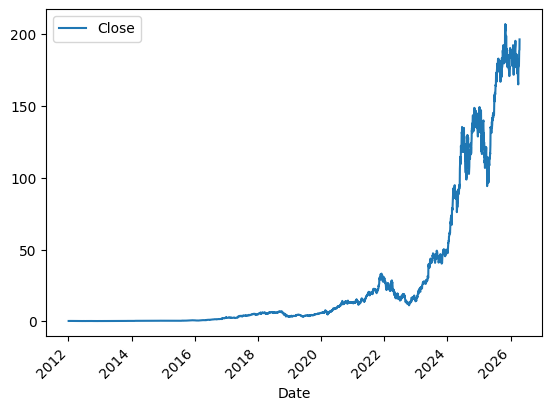

In [ ]:
df.plot (x='Date', y='Close')
plt.xticks(rotation = 45)

In [ ]:
model = RandomForestRegressor()

In [ ]:
X = df[['Open', 'High', 'Low', 'Volume']]
X = X[:int(len(df) - 1)]

y = df['Close']
y = y[:int(len(df) -1)]
model.fit(X,y)

RandomForestRegressor()

In [ ]:
predictions = model.predict(X)
print('The model Score is:', model.score(X,y))

The model Score is: 0.9999678865321582


In [ ]:
new_data = df[['Open', 'High', 'Low', 'Volume']].tail(1)
prediction = model.predict(new_data)
print('The model predicts the last price is:', prediction)
print('The actual value is:', df[['Close']].tail(1).values[0][0])

The model predicts the last price is: [192.58503754]
The actual value is: 196.50999450683594


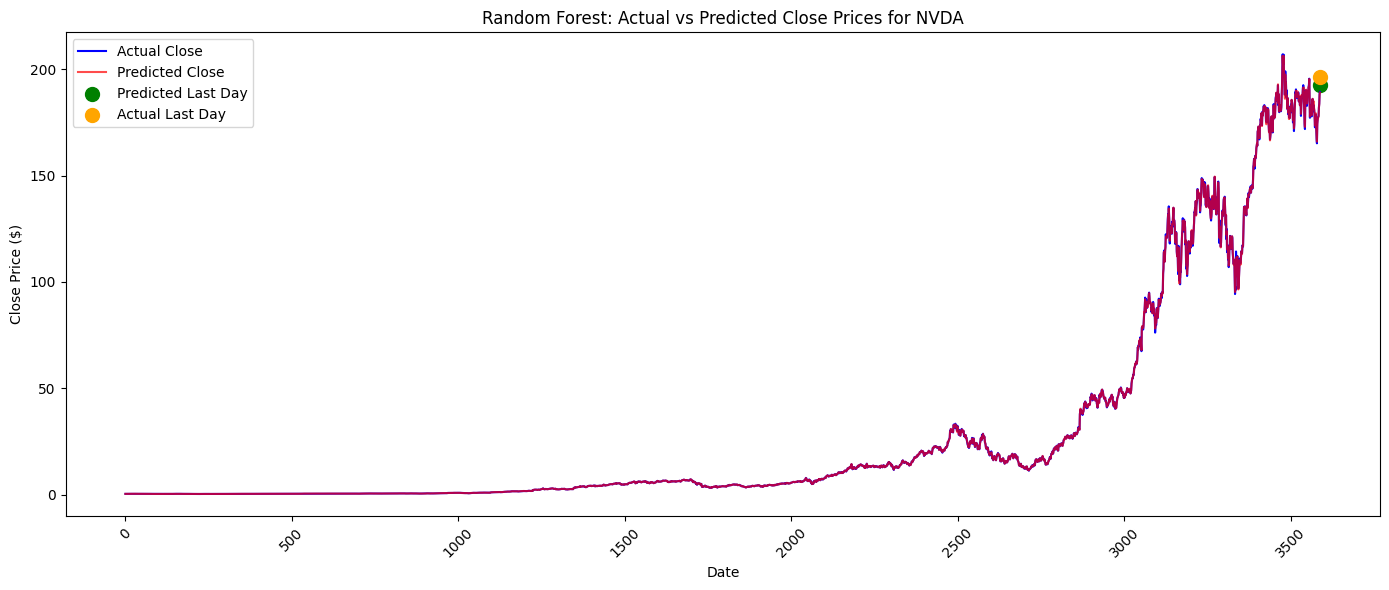

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(df.index[:-1], y, label='Actual Close', color='blue')
plt.plot(df.index[:-1], predictions, label='Predicted Close', color='red', alpha=0.7)
plt.scatter(df.index[-1], prediction[0], color='green', s=100, label='Predicted Last Day')
plt.scatter(df.index[-1], df['Close'].iloc[-1], color='orange', s=100, label='Actual Last Day')


plt.title('Random Forest: Actual vs Predicted Close Prices for NVDA')
plt.xlabel('Date')
plt.ylabel('Close Price ($)')
plt.xticks(rotation=45)  # rotate labels so they don’t overlap
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y, predictions)
mse = mean_squared_error(y, predictions)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

Mean Absolute Error (MAE): 0.1114
Mean Squared Error (MSE): 0.0821
Root Mean Squared Error (RMSE): 0.2866
